### What this phase does

Phase 4 moves beyond tabular models into sequence-aware deep learning and geospatial analysis:

| Component | Method | Goal |
|-----------|--------|------|
| **4A — LSTM** | Sequence model per ride | Predict delay at each stop using the full delay history of earlier stops in the same ride |
| **4B — Autoencoder** | Unsupervised reconstruction | Flag stops whose delay pattern is anomalous (unusually large reconstruction error) |
| **4C — Geo Clustering** | K-Means on lat/lon | Group stations into geographic delay hotspots; map cluster-level delay statistics |
| **4D — Transformer** | Self-attention on sequences | Bonus: compare attention-based sequence model against LSTM |

### Why LSTM is appropriate here
Each ride is a **sequence** of stops ordered by `stop_number`. The delay at stop N is causally influenced by delays at stops 1…N-1. Tabular models (Phases 2-3) approximated this with lag features; the LSTM captures the full temporal structure by processing the complete stop sequence as input.

### Evaluation
- **LSTM / Transformer**: MAE, RMSE, R² on per-stop delay predictions (regression)
- **Autoencoder**: reconstruction error distribution; anomaly threshold at 95th percentile
- **Geo clustering**: silhouette score; mean delay per cluster; hotspot map

### Prerequisites
Phase 1 → `outputs/db_train.parquet`, `outputs/db_test.parquet`, `outputs/config.json`  
Phase 2 → `outputs/phase2_config.json`  
Phase 3 → `outputs/phase3_config.json`

In [1]:
# ════════════════════════════════════════════════════════════
# CELL 1 · IMPORTS
# ════════════════════════════════════════════════════════════

import warnings, json, time, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from IPython.display import display

warnings.filterwarnings("ignore")
np.random.seed(42)

# ── Scikit-learn (clustering + metrics) ───────────────────────
from sklearn.preprocessing   import StandardScaler, MinMaxScaler
from sklearn.cluster         import KMeans
from sklearn.metrics         import (mean_absolute_error,
                                     mean_squared_error,
                                     r2_score,
                                     silhouette_score)

# ── TensorFlow / Keras ────────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks as K_CB, Model
tf.random.set_seed(42)

# ── Paths ─────────────────────────────────────────────────────
OUTPUT_DIR = Path("outputs")
FIG_DIR    = OUTPUT_DIR / "figures"
MODEL_DIR  = OUTPUT_DIR / "models"
FIG_DIR.mkdir(exist_ok=True)
MODEL_DIR.mkdir(exist_ok=True)

# ── Plot style — matches previous phases ─────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
PAL     = sns.color_palette("muted", 12)
FIG_DPI = 150

print("✅  Phase 4 imports ready.")
print(f"   TensorFlow version : {tf.__version__}")


✅  Phase 4 imports ready.
   TensorFlow version : 2.10.0


In [2]:
# ════════════════════════════════════════════════════════════
# CELL 2 · LOAD PHASE 1-3 OUTPUTS
# ════════════════════════════════════════════════════════════

df_train = pd.read_parquet(OUTPUT_DIR / "db_train.parquet")
df_test  = pd.read_parquet(OUTPUT_DIR / "db_test.parquet")

with open(OUTPUT_DIR / "config.json") as f:
    cfg = json.load(f)
with open(OUTPUT_DIR / "phase2_config.json") as f:
    p2_cfg = json.load(f)
with open(OUTPUT_DIR / "phase3_config.json") as f:
    p3_cfg = json.load(f)

TARGET          = cfg["TARGET_REG"]          # "delay_in_min"
LAG_FEATURES    = cfg["LAG_FEATURES"]
WEATHER_FEATURES = cfg["WEATHER_FEATURES"]
CONGESTION_FEATURES = cfg["CONGESTION_FEATURES"]
FEATURES_TREE   = [f for f in cfg["FEATURES_TREE"] if f in df_train.columns]

CLASS_LABELS = {0: "On time/early", 1: "Slight (1-5m)",
                2: "Moderate (6-15m)", 3: "Severe (>15m)"}

# ── Confirm ride-based split ──────────────────────────────────
split_strategy = cfg.get("split_strategy", "unknown")
assert "ride_based" in split_strategy, "Re-run Phase 1 (v4) first."
train_rides = set(df_train["train_line_ride_id"].unique())
test_rides  = set(df_test["train_line_ride_id"].unique())
assert len(train_rides & test_rides) == 0, "Ride overlap detected!"
print(f"Split strategy   : {split_strategy}  ✅")
print(f"Ride overlap     : 0  ✅")

print(f"\nTrain : {len(df_train):,} rows  |  {df_train['train_line_ride_id'].nunique():,} rides")
print(f"Test  : {len(df_test):,} rows  |  {df_test['train_line_ride_id'].nunique():,} rides")
print(f"\nTarget column    : {TARGET}")
print(f"  Train mean delay: {df_train[TARGET].mean():.3f} min")
print(f"  Test  mean delay: {df_test[TARGET].mean():.3f} min")

print(f"\nPhase 2 best MAE : {p2_cfg['best_mae']:.3f} min  ({p2_cfg['best_model_name']})")
print(f"Phase 3 best F1  : {p3_cfg['best_macro_f1']:.4f}  ({p3_cfg['best_model_name']})")
print("\nPhase 4 will now build LSTM, Autoencoder, Geo Clustering, Transformer.")


Split strategy   : ride_based_GroupShuffleSplit  ✅
Ride overlap     : 0  ✅

Train : 715,232 rows  |  114,497 rides
Test  : 178,310 rows  |  28,625 rides

Target column    : delay_in_min
  Train mean delay: 2.607 min
  Test  mean delay: 2.573 min

Phase 2 best MAE : 0.913 min  (MLP Neural Network)
Phase 3 best F1  : 0.7793  (LightGBM)

Phase 4 will now build LSTM, Autoencoder, Geo Clustering, Transformer.


In [3]:
# ════════════════════════════════════════════════════════════
# CELL 3 · BUILD RIDE SEQUENCES FOR LSTM & TRANSFORMER
#
# Each ride is an ordered sequence of stops (by stop_number).
# For each stop position t we want:
#   INPUT  : features of stops 0 … t-1  (look-back window)
#   TARGET : delay_in_min at stop t
#
# We use a fixed-length look-back window (LOOKBACK stops).
# Rides shorter than LOOKBACK+1 are zero-padded on the left.
#
# Feature set for the LSTM:
#   - delay_in_min (prior stops only — no leakage at current stop)
#   - stop_number, hour, day_of_week, is_weekend
#   - weather features available at stop time
#   - congestion features
#
# LEAKAGE RULE: the delay at the CURRENT stop (position t) is
# the TARGET. We only include delays from positions 0…t-1.
# This is naturally enforced by the windowing: the sequence
# fed to the LSTM covers stops [t-LOOKBACK … t-1] and the
# label is the delay at stop t.
# ════════════════════════════════════════════════════════════

LOOKBACK = 5   # how many previous stops to look back
               # 5 is realistic: most German routes have 5-25 stops

# ── Select sequence features ──────────────────────────────────
# Use only features that exist in both splits
SEQ_CANDIDATES = (
    ["delay_in_min", "stop_number", "hour", "day_of_week",
     "is_weekend", "is_first_stop", "planned_dwell_min"]
    + [f for f in WEATHER_FEATURES    if f in df_train.columns]
    + [f for f in CONGESTION_FEATURES if f in df_train.columns]
)
SEQ_FEATURES = [f for f in SEQ_CANDIDATES if f in df_train.columns]
N_FEATURES   = len(SEQ_FEATURES)
print(f"Sequence features ({N_FEATURES}): {SEQ_FEATURES}")

def build_sequences(df, lookback, feature_cols, target_col, min_stops=2):
    """
    For every ride in df, build (X, y) pairs where:
      X[i] shape: (lookback, n_features)  — prior stops, zero-padded
      y[i] scalar                         — delay at current stop

    The current stop's delay is EXCLUDED from X to avoid leakage.
    Only delay values from strictly earlier stops appear in X.
    """
    Xs, ys, ride_ids, stop_nums = [], [], [], []

    df_sorted = df.sort_values(
        ["train_line_ride_id", "stop_number"]
    ).reset_index(drop=True)

    for ride_id, grp in df_sorted.groupby("train_line_ride_id", sort=False):
        grp = grp.reset_index(drop=True)
        if len(grp) < min_stops:
            continue

        vals = grp[feature_cols].fillna(0).values.astype("float32")
        # Zero out delay_in_min column at index 0 (it's the first feature)
        # for each position so that the current stop target is never in X
        delay_col_idx = feature_cols.index(target_col) if target_col in feature_cols else None

        for t in range(1, len(grp)):   # t=0 has no prior stops to look back on
            # Window covers stops max(0, t-lookback) … t-1
            window = vals[max(0, t - lookback): t]

            # Pad on the LEFT with zeros if window < lookback
            pad_len = lookback - len(window)
            if pad_len > 0:
                pad = np.zeros((pad_len, len(feature_cols)), dtype="float32")
                window = np.vstack([pad, window])

            # LEAKAGE GUARD: if delay_in_min is in features, the window
            # already only contains stops 0…t-1 (past stops).
            # The current stop's delay (vals[t, delay_col_idx]) is used
            # ONLY as the label y, never in X.
            Xs.append(window)
            ys.append(float(grp[target_col].iloc[t]))
            ride_ids.append(ride_id)
            stop_nums.append(int(grp["stop_number"].iloc[t]))

    X = np.array(Xs, dtype="float32")   # (n_samples, lookback, n_features)
    y = np.array(ys, dtype="float32")   # (n_samples,)
    return X, y, ride_ids, stop_nums

print("\nBuilding training sequences ...")
t0 = time.time()
X_train_seq, y_train_seq, _, _ = build_sequences(
    df_train, LOOKBACK, SEQ_FEATURES, TARGET
)
t1 = time.time()
print(f"  X_train_seq : {X_train_seq.shape}  [{t1-t0:.1f}s]")
print(f"  y_train_seq : {y_train_seq.shape}  mean={y_train_seq.mean():.3f}")

print("\nBuilding test sequences ...")
t0 = time.time()
X_test_seq, y_test_seq, test_ride_ids, test_stop_nums = build_sequences(
    df_test, LOOKBACK, SEQ_FEATURES, TARGET
)
t1 = time.time()
print(f"  X_test_seq  : {X_test_seq.shape}  [{t1-t0:.1f}s]")
print(f"  y_test_seq  : {y_test_seq.shape}  mean={y_test_seq.mean():.3f}")

# ── Scale sequences ───────────────────────────────────────────
# Fit scaler on training data only (flatten → fit → reshape)
n_tr, L, F = X_train_seq.shape
seq_scaler  = StandardScaler()
X_train_sc  = seq_scaler.fit_transform(
    X_train_seq.reshape(-1, F)
).reshape(n_tr, L, F).astype("float32")

n_te = X_test_seq.shape[0]
X_test_sc  = seq_scaler.transform(
    X_test_seq.reshape(-1, F)
).reshape(n_te, L, F).astype("float32")

joblib.dump(seq_scaler, MODEL_DIR / "p4_seq_scaler.pkl")
print(f"\nSequence scaler saved -> outputs/models/p4_seq_scaler.pkl")

# ── Target scaler (for LSTM output) ───────────────────────────
# We keep y in original minutes for interpretable MAE.
y_mean = float(y_train_seq.mean())
y_std  = float(y_train_seq.std())
y_train_norm = ((y_train_seq - y_mean) / y_std).astype("float32")
y_test_norm  = ((y_test_seq  - y_mean) / y_std).astype("float32")

print(f"\nTarget normalisation: mean={y_mean:.3f}, std={y_std:.3f}")
print(f"  y_train_norm: mean={y_train_norm.mean():.3f}, std={y_train_norm.std():.3f}")

# ── ES validation split (10% of training sequences) ───────────
n_val_seq     = int(len(X_train_sc) * 0.10)
X_seq_fit     = X_train_sc[:-n_val_seq]
y_seq_fit     = y_train_norm[:-n_val_seq]
X_seq_val     = X_train_sc[-n_val_seq:]
y_seq_val     = y_train_norm[-n_val_seq:]
print(f"\nEarly-stopping validation (from training only):")
print(f"  X_seq_fit : {X_seq_fit.shape}  (90%)")
print(f"  X_seq_val : {X_seq_val.shape}  (10%)")


Sequence features (24): ['delay_in_min', 'stop_number', 'hour', 'day_of_week', 'is_weekend', 'is_first_stop', 'planned_dwell_min', 'temp', 'prcp', 'snow', 'wspd', 'wpgt', 'is_raining', 'heavy_rain', 'is_snowing', 'is_freezing', 'near_freeze', 'extreme_heat', 'deep_freeze', 'weather_disruption', 'is_bad_weather', 'winter_severity', 'trains_this_hour', 'congestion_ratio']

Building training sequences ...
  X_train_seq : (600735, 5, 24)  [131.2s]
  y_train_seq : (600735,)  mean=2.832

Building test sequences ...
  X_test_seq  : (149685, 5, 24)  [31.8s]
  y_test_seq  : (149685,)  mean=2.800

Sequence scaler saved -> outputs/models/p4_seq_scaler.pkl

Target normalisation: mean=2.832, std=5.824
  y_train_norm: mean=0.000, std=1.000

Early-stopping validation (from training only):
  X_seq_fit : (540662, 5, 24)  (90%)
  X_seq_val : (60073, 5, 24)  (10%)


In [4]:
# ════════════════════════════════════════════════════════════
# CELL 4A · LSTM DELAY SEQUENCE MODEL
#
# Architecture:
#   Input  : (LOOKBACK, N_FEATURES)
#   LSTM 1 : 64 units, return_sequences=True
#   Dropout: 0.20
#   LSTM 2 : 32 units, return_sequences=False
#   Dropout: 0.20
#   Dense  : 16 units, ReLU
#   Output : 1 unit, linear  (normalised delay)
#
# Two LSTM layers allow the first to learn local stop-to-stop
# transition patterns, and the second to summarise the full
# look-back window into a fixed-length context vector.
#
# The output is in normalised space; we un-normalise for eval.
# ════════════════════════════════════════════════════════════

print("=" * 72)
print("  PHASE 4A — LSTM DELAY SEQUENCE MODEL")
print("=" * 72)

lstm_input = keras.Input(shape=(LOOKBACK, N_FEATURES), name="sequence_input")
x = layers.LSTM(64, return_sequences=True, name="lstm_1")(lstm_input)
x = layers.Dropout(0.20, name="drop_1")(x)
x = layers.LSTM(32, return_sequences=False, name="lstm_2")(x)
x = layers.Dropout(0.20, name="drop_2")(x)
x = layers.Dense(16, activation="relu", name="dense_1")(x)
lstm_out = layers.Dense(1, activation="linear", name="output")(x)

lstm_model = Model(inputs=lstm_input, outputs=lstm_out, name="LSTM_delay_seq")
lstm_model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=1e-3),
    loss      = "mse",
    metrics   = ["mae"],
)
lstm_model.summary()

cb_lstm = [
    K_CB.EarlyStopping(monitor="val_loss", patience=10,
                       restore_best_weights=True, verbose=1),
    K_CB.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                            patience=5, min_lr=1e-6, verbose=0),
]

t0 = time.time()
hist_lstm = lstm_model.fit(
    X_seq_fit, y_seq_fit,
    validation_data = (X_seq_val, y_seq_val),
    epochs          = 60,
    batch_size      = 512,
    callbacks       = cb_lstm,
    verbose         = 1,
)
t1 = time.time()
train_time_lstm = t1 - t0

# ── Evaluate ─────────────────────────────────────────────────
pred_lstm_norm = lstm_model.predict(X_test_sc, verbose=0).flatten()
pred_lstm      = pred_lstm_norm * y_std + y_mean   # back to minutes

mae_lstm  = mean_absolute_error(y_test_seq, pred_lstm)
rmse_lstm = float(np.sqrt(mean_squared_error(y_test_seq, pred_lstm)))
r2_lstm   = r2_score(y_test_seq, pred_lstm)

print(f"\n  LSTM results:")
print(f"  MAE  : {mae_lstm:.4f} min")
print(f"  RMSE : {rmse_lstm:.4f} min")
print(f"  R²   : {r2_lstm:.4f}")
print(f"  Time : {train_time_lstm:.1f}s")
print(f"\n  Phase 2 best MAE for reference: {p2_cfg['best_mae']:.4f} min")

lstm_model.save(str(MODEL_DIR / "p4_lstm.keras"))
joblib.dump(seq_scaler, MODEL_DIR / "p4_seq_scaler.pkl")
print("  Saved -> outputs/models/p4_lstm.keras")


  PHASE 4A — LSTM DELAY SEQUENCE MODEL
Model: "LSTM_delay_seq"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequence_input (InputLayer)  [(None, 5, 24)]          0         
                                                                 
 lstm_1 (LSTM)               (None, 5, 64)             22784     
                                                                 
 drop_1 (Dropout)            (None, 5, 64)             0         
                                                                 
 lstm_2 (LSTM)               (None, 32)                12416     
                                                                 
 drop_2 (Dropout)            (None, 32)                0         
                                                                 
 dense_1 (Dense)             (None, 16)                528       
                                                                 
 output (Dens

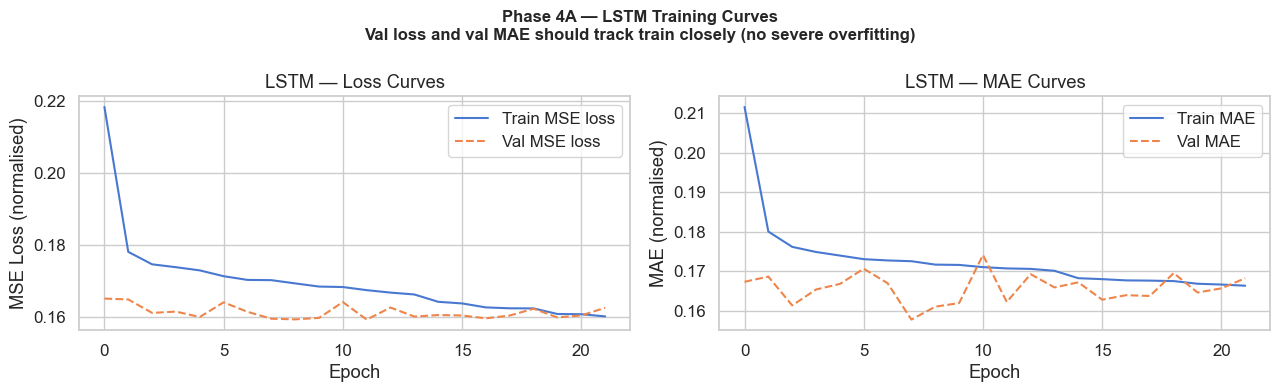

In [5]:
# ════════════════════════════════════════════════════════════
# CELL 4A-CHART · LSTM TRAINING CURVES
# ════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(hist_lstm.history["loss"],     label="Train MSE loss", color=PAL[0])
axes[0].plot(hist_lstm.history["val_loss"], label="Val MSE loss",   color=PAL[1], ls="--")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("MSE Loss (normalised)")
axes[0].set_title("LSTM — Loss Curves"); axes[0].legend()

axes[1].plot(hist_lstm.history["mae"],     label="Train MAE", color=PAL[0])
axes[1].plot(hist_lstm.history["val_mae"], label="Val MAE",   color=PAL[1], ls="--")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("MAE (normalised)")
axes[1].set_title("LSTM — MAE Curves"); axes[1].legend()

plt.suptitle("Phase 4A — LSTM Training Curves\n"
             "Val loss and val MAE should track train closely (no severe overfitting)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "p4_01_lstm_training.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()


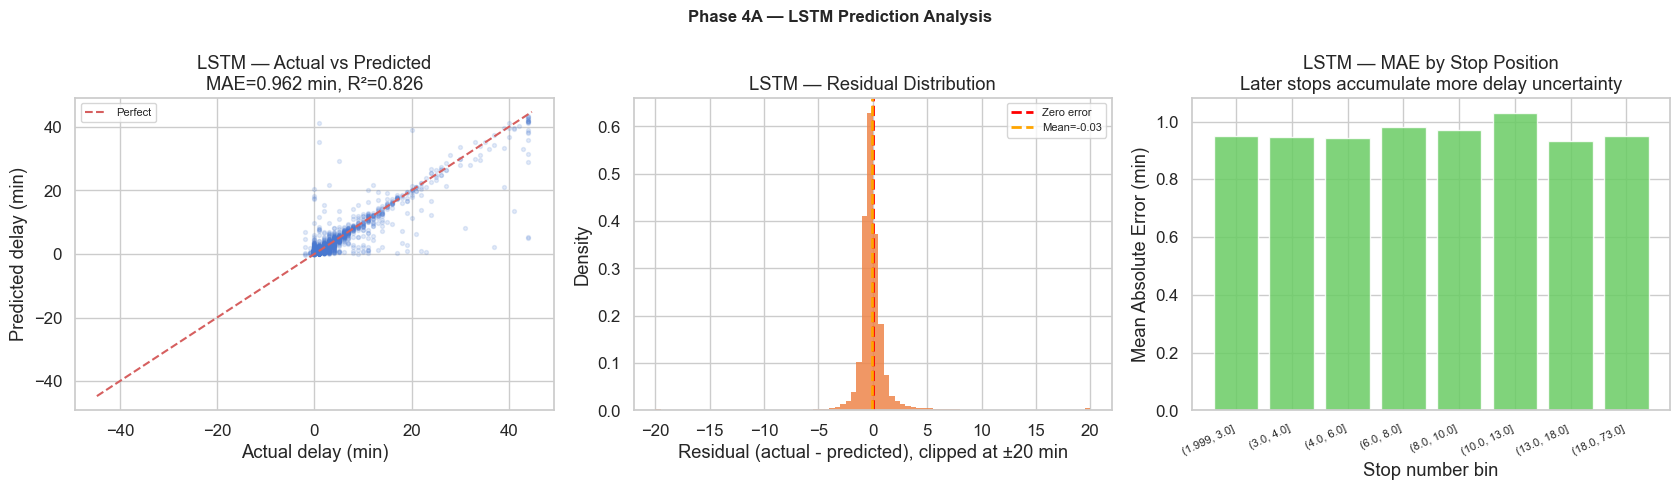

In [6]:
# ════════════════════════════════════════════════════════════
# CELL 4A-CHART 2 · LSTM PREDICTION ANALYSIS
# ════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# (a) Actual vs Predicted scatter (sample 3000 points for clarity)
n_scatter = min(3000, len(y_test_seq))
rng       = np.random.default_rng(42)
idx_sc    = rng.choice(len(y_test_seq), n_scatter, replace=False)
lim       = max(abs(y_test_seq.max()), abs(pred_lstm.max()))
axes[0].scatter(y_test_seq[idx_sc], pred_lstm[idx_sc],
                alpha=0.15, s=8, color=PAL[0])
axes[0].plot([-lim, lim], [-lim, lim], "r--", lw=1.5, label="Perfect")
axes[0].set_xlabel("Actual delay (min)")
axes[0].set_ylabel("Predicted delay (min)")
axes[0].set_title(f"LSTM — Actual vs Predicted\nMAE={mae_lstm:.3f} min, R²={r2_lstm:.3f}")
axes[0].legend(fontsize=8)

# (b) Residual distribution
residuals = y_test_seq - pred_lstm
axes[1].hist(residuals.clip(-20, 20), bins=80,
             color=PAL[1], alpha=0.85, edgecolor="none", density=True)
axes[1].axvline(0, color="red", lw=2, ls="--", label="Zero error")
axes[1].axvline(residuals.mean(), color="orange", lw=2, ls="--",
                label=f"Mean={residuals.mean():.2f}")
axes[1].set_xlabel("Residual (actual - predicted), clipped at ±20 min")
axes[1].set_ylabel("Density")
axes[1].set_title("LSTM — Residual Distribution")
axes[1].legend(fontsize=8)

# (c) MAE by stop position (does model improve as ride progresses?)
stop_df = pd.DataFrame({
    "stop_num" : test_stop_nums,
    "actual"   : y_test_seq,
    "predicted": pred_lstm,
})
stop_df["abs_err"] = np.abs(stop_df["actual"] - stop_df["predicted"])
# Bin stop numbers into deciles for stable estimates
stop_df["stop_bin"] = pd.qcut(stop_df["stop_num"], q=8, duplicates="drop")
bin_mae = stop_df.groupby("stop_bin", observed=True)["abs_err"].mean()

axes[2].bar(range(len(bin_mae)), bin_mae.values, color=PAL[2], alpha=0.85)
axes[2].set_xticks(range(len(bin_mae)))
axes[2].set_xticklabels(
    [str(b) for b in bin_mae.index], rotation=25, ha="right", fontsize=8
)
axes[2].set_xlabel("Stop number bin")
axes[2].set_ylabel("Mean Absolute Error (min)")
axes[2].set_title("LSTM — MAE by Stop Position\n"
                  "Later stops accumulate more delay uncertainty")

plt.suptitle("Phase 4A — LSTM Prediction Analysis", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "p4_02_lstm_predictions.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()


In [7]:
# ════════════════════════════════════════════════════════════
# CELL 4B · LSTM AUTOENCODER — ANOMALY DETECTION
#
# An autoencoder is trained ONLY on normal training sequences.
# It learns to reconstruct typical delay patterns.
# At inference, high reconstruction error = anomalous stop.
#
# Architecture (sequence autoencoder):
#   Encoder: LSTM 32 → bottleneck (8-dim dense)
#   Decoder: RepeatVector(LOOKBACK) → LSTM 32 → TimeDistributed Dense
#
# Anomaly threshold: 95th percentile of training reconstruction error.
# Any test stop above this threshold is flagged as anomalous.
#
# "Normal" is defined as: delay_in_min in the training set
# (which covers the bulk of the delay distribution after clipping).
# ════════════════════════════════════════════════════════════

print("\n" + "=" * 72)
print("  PHASE 4B — AUTOENCODER ANOMALY DETECTION")
print("=" * 72)

BOTTLENECK = 8   # compressed representation dimension

# ── Encoder ───────────────────────────────────────────────────
enc_input = keras.Input(shape=(LOOKBACK, N_FEATURES), name="ae_input")
enc_x     = layers.LSTM(32, return_sequences=False, name="ae_enc_lstm")(enc_input)
bottleneck = layers.Dense(BOTTLENECK, activation="relu", name="bottleneck")(enc_x)

# ── Decoder ───────────────────────────────────────────────────
dec_x = layers.RepeatVector(LOOKBACK, name="repeat")(bottleneck)
dec_x = layers.LSTM(32, return_sequences=True, name="ae_dec_lstm")(dec_x)
dec_out = layers.TimeDistributed(
    layers.Dense(N_FEATURES), name="ae_output"
)(dec_x)

ae_model = Model(inputs=enc_input, outputs=dec_out, name="LSTM_Autoencoder")
ae_model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=1e-3),
    loss      = "mse",
)
ae_model.summary()

cb_ae = [
    K_CB.EarlyStopping(monitor="val_loss", patience=10,
                       restore_best_weights=True, verbose=1),
    K_CB.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                            patience=5, min_lr=1e-6, verbose=0),
]

# Train to reconstruct the input sequence (X -> X)
t0 = time.time()
hist_ae = ae_model.fit(
    X_seq_fit, X_seq_fit,               # input = target (reconstruction)
    validation_data = (X_seq_val, X_seq_val),
    epochs          = 60,
    batch_size      = 512,
    callbacks       = cb_ae,
    verbose         = 1,
)
t1 = time.time()
print(f"\n  Autoencoder trained in {t1-t0:.1f}s")

# ── Compute reconstruction errors ─────────────────────────────
# Per-sample MSE across all time steps and features
X_train_recon  = ae_model.predict(X_train_sc, verbose=0)
train_recon_err = np.mean((X_train_sc - X_train_recon) ** 2, axis=(1, 2))

X_test_recon   = ae_model.predict(X_test_sc, verbose=0)
test_recon_err  = np.mean((X_test_sc - X_test_recon) ** 2, axis=(1, 2))

# Anomaly threshold: 95th percentile of TRAINING reconstruction errors
ANOMALY_THRESHOLD = float(np.percentile(train_recon_err, 95))
print(f"\n  Reconstruction error (train):")
print(f"    Mean   : {train_recon_err.mean():.6f}")
print(f"    Std    : {train_recon_err.std():.6f}")
print(f"    95th pct (threshold): {ANOMALY_THRESHOLD:.6f}")
print(f"\n  Reconstruction error (test):")
print(f"    Mean   : {test_recon_err.mean():.6f}")
print(f"    Std    : {test_recon_err.std():.6f}")

anomaly_flags = test_recon_err > ANOMALY_THRESHOLD
n_anomalies   = anomaly_flags.sum()
print(f"\n  Test stops flagged as anomalous : {n_anomalies:,} / {len(test_recon_err):,}"
      f"  ({n_anomalies/len(test_recon_err)*100:.1f}%)")
print("  (Expected ~5% by construction of the 95th-pct threshold)")

ae_model.save(str(MODEL_DIR / "p4_autoencoder.keras"))
print("  Saved -> outputs/models/p4_autoencoder.keras")

# Save anomaly results for Phase 5 analysis
ae_results = pd.DataFrame({
    "recon_error": test_recon_err,
    "is_anomaly" : anomaly_flags.astype(int),
    "actual_delay": y_test_seq,
    "stop_num"   : test_stop_nums,
})
ae_results.to_parquet(OUTPUT_DIR / "phase4_anomaly_results.parquet", index=False)
print("  Anomaly results -> outputs/phase4_anomaly_results.parquet")



  PHASE 4B — AUTOENCODER ANOMALY DETECTION
Model: "LSTM_Autoencoder"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 ae_input (InputLayer)       [(None, 5, 24)]           0         
                                                                 
 ae_enc_lstm (LSTM)          (None, 32)                7296      
                                                                 
 bottleneck (Dense)          (None, 8)                 264       
                                                                 
 repeat (RepeatVector)       (None, 5, 8)              0         
                                                                 
 ae_dec_lstm (LSTM)          (None, 5, 32)             5248      
                                                                 
 ae_output (TimeDistributed)  (None, 5, 24)            792       
                                                                 
Total 

  Mean delay — Normal stops  : 2.61 min
  Mean delay — Anomaly stops : 6.10 min


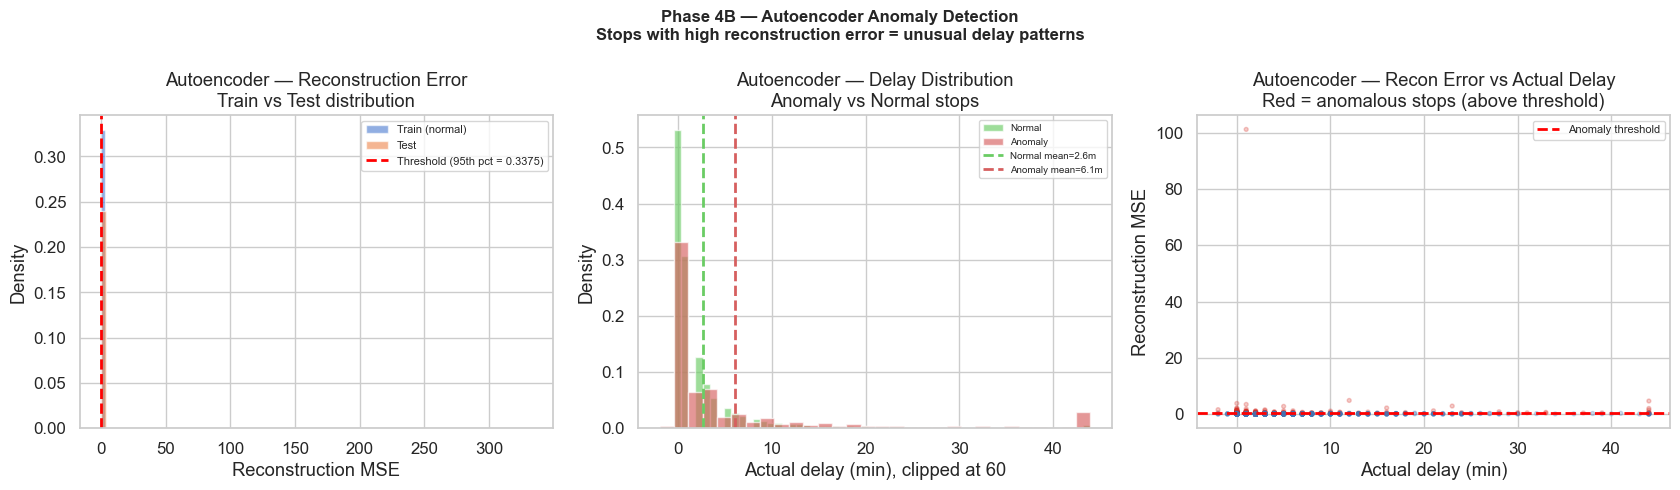

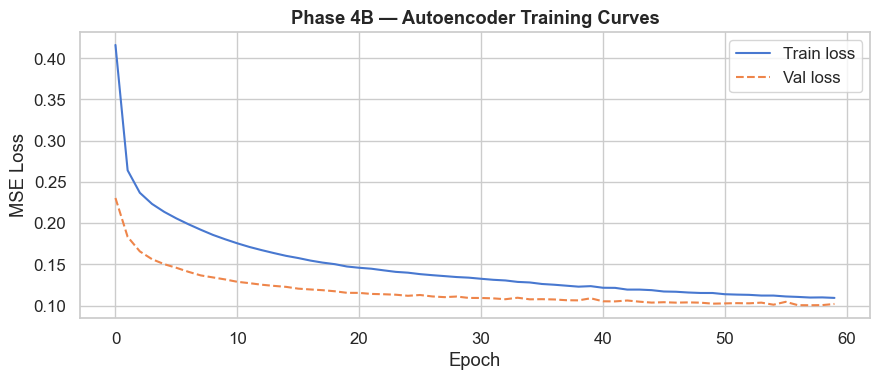

In [8]:
# ════════════════════════════════════════════════════════════
# CELL 4B-CHART · AUTOENCODER ANOMALY ANALYSIS
# ════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# (a) Reconstruction error distribution: train vs test
axes[0].hist(train_recon_err, bins=80, alpha=0.60, density=True,
             color=PAL[0], label="Train (normal)")
axes[0].hist(test_recon_err,  bins=80, alpha=0.60, density=True,
             color=PAL[1], label="Test")
axes[0].axvline(ANOMALY_THRESHOLD, color="red", lw=2, ls="--",
                label=f"Threshold (95th pct = {ANOMALY_THRESHOLD:.4f})")
axes[0].set_xlabel("Reconstruction MSE")
axes[0].set_ylabel("Density")
axes[0].set_title("Autoencoder — Reconstruction Error\nTrain vs Test distribution")
axes[0].legend(fontsize=8)

# (b) Anomalous vs normal: actual delay distribution
ax = axes[1]
ax.hist(y_test_seq[~anomaly_flags].clip(-5, 60), bins=60,
        alpha=0.65, density=True, color=PAL[2], label="Normal")
ax.hist(y_test_seq[anomaly_flags].clip(-5, 60),  bins=30,
        alpha=0.65, density=True, color=PAL[3], label="Anomaly")
ax.set_xlabel("Actual delay (min), clipped at 60")
ax.set_ylabel("Density")
ax.set_title("Autoencoder — Delay Distribution\nAnomaly vs Normal stops")
ax.legend(fontsize=8)

mean_normal  = y_test_seq[~anomaly_flags].mean()
mean_anomaly = y_test_seq[anomaly_flags].mean()
ax.axvline(mean_normal,  color=PAL[2], lw=2, ls="--",
           label=f"Normal mean={mean_normal:.1f}m")
ax.axvline(mean_anomaly, color=PAL[3], lw=2, ls="--",
           label=f"Anomaly mean={mean_anomaly:.1f}m")
ax.legend(fontsize=7)

print(f"  Mean delay — Normal stops  : {mean_normal:.2f} min")
print(f"  Mean delay — Anomaly stops : {mean_anomaly:.2f} min")

# (c) Reconstruction error vs actual delay (scatter sample)
n_sc = min(3000, len(test_recon_err))
idx_sc = np.random.default_rng(0).choice(len(test_recon_err), n_sc, replace=False)
sc_colors = np.where(anomaly_flags[idx_sc], "#d73027", "#4575b4")
axes[2].scatter(y_test_seq[idx_sc], test_recon_err[idx_sc],
                c=sc_colors, alpha=0.25, s=8)
axes[2].axhline(ANOMALY_THRESHOLD, color="red", lw=2, ls="--",
                label=f"Anomaly threshold")
axes[2].set_xlabel("Actual delay (min)")
axes[2].set_ylabel("Reconstruction MSE")
axes[2].set_title("Autoencoder — Recon Error vs Actual Delay\n"
                  "Red = anomalous stops (above threshold)")
axes[2].legend(fontsize=8)

plt.suptitle("Phase 4B — Autoencoder Anomaly Detection\n"
             "Stops with high reconstruction error = unusual delay patterns",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "p4_03_autoencoder_anomaly.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

# Autoencoder training curve
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(hist_ae.history["loss"],     label="Train loss", color=PAL[0])
ax.plot(hist_ae.history["val_loss"], label="Val loss",   color=PAL[1], ls="--")
ax.set_xlabel("Epoch"); ax.set_ylabel("MSE Loss")
ax.set_title("Phase 4B — Autoencoder Training Curves", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "p4_04_ae_training.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()


In [9]:
# ════════════════════════════════════════════════════════════
# CELL 4C · GEOSPATIAL CLUSTERING — K-MEANS ON LAT/LON
#
# Goal: find geographic delay hotspots across the DB network.
#
# Method:
#   1. Aggregate per-station: mean delay, % severely delayed,
#      station coordinates (lat, lon from Phase 1 geocoding).
#   2. K-Means on (lat, lon) only — clusters are geographic zones.
#   3. Analyse delay statistics per cluster.
#   4. Map clusters using matplotlib scatter plot (no external
#      mapping libraries required — just lon/lat projected).
#
# K selection: we test K=3…10 and use the elbow + silhouette.
# ════════════════════════════════════════════════════════════

print("\n" + "=" * 72)
print("  PHASE 4C — GEOSPATIAL CLUSTERING")
print("=" * 72)

# ── Confirm lat/lon exist ─────────────────────────────────────
NEED_COLS = ["lat", "lon", "station_name", "delay_in_min", "delay_class"]
missing   = [c for c in NEED_COLS if c not in df_train.columns]
if missing:
    print(f"❌  Missing columns: {missing}")
    print("   These are created in Phase 1 (geocoding cell).")
    print("   Re-run Phase 1 or skip to Cell 10.")
    GEO_AVAILABLE = False
else:
    GEO_AVAILABLE = True
    print(f"✅  Geo columns available: lat, lon, station_name")

if GEO_AVAILABLE:
    # ── Build per-station stats (train + test combined) ───────
    df_all = pd.concat([df_train, df_test], ignore_index=True)

    station_stats = (
        df_all.groupby("station_name")
        .agg(
            lat         = ("lat",           "first"),
            lon         = ("lon",           "first"),
            mean_delay  = ("delay_in_min",  "mean"),
            median_delay= ("delay_in_min",  "median"),
            std_delay   = ("delay_in_min",  "std"),
            pct_severe  = ("delay_class",   lambda x: (x >= 3).mean() * 100),
            pct_delayed = ("delay_class",   lambda x: (x >= 2).mean() * 100),
            n_stops     = ("delay_in_min",  "count"),
        )
        .reset_index()
    )

    # Drop stations with missing coords or very few observations
    station_stats = station_stats.dropna(subset=["lat", "lon"])
    station_stats = station_stats[station_stats["n_stops"] >= 10].copy()

    # Remove obvious geocoding failures (outside Germany rough bbox)
    station_stats = station_stats[
        (station_stats["lat"].between(47.0, 55.5)) &
        (station_stats["lon"].between(5.5, 15.5))
    ].copy().reset_index(drop=True)

    print(f"\nStations with valid geo + >= 10 stops: {len(station_stats):,}")
    print(f"  Lat range: {station_stats['lat'].min():.3f} – {station_stats['lat'].max():.3f}")
    print(f"  Lon range: {station_stats['lon'].min():.3f} – {station_stats['lon'].max():.3f}")
    print(f"  Mean delay: {station_stats['mean_delay'].mean():.3f} min")



  PHASE 4C — GEOSPATIAL CLUSTERING
✅  Geo columns available: lat, lon, station_name

Stations with valid geo + >= 10 stops: 5,272
  Lat range: 47.411 – 54.907
  Lon range: 6.071 – 14.979
  Mean delay: 2.550 min


  K= 2 | Inertia=   20567.9 | Silhouette=0.4251
  K= 3 | Inertia=   13332.7 | Silhouette=0.4115
  K= 4 | Inertia=    9597.8 | Silhouette=0.4187
  K= 5 | Inertia=    7254.1 | Silhouette=0.4171
  K= 6 | Inertia=    5844.2 | Silhouette=0.4135
  K= 7 | Inertia=    5127.3 | Silhouette=0.3972
  K= 8 | Inertia=    4513.6 | Silhouette=0.3968
  K= 9 | Inertia=    4007.6 | Silhouette=0.3909
  K=10 | Inertia=    3627.7 | Silhouette=0.3931
  K=11 | Inertia=    3314.2 | Silhouette=0.3931


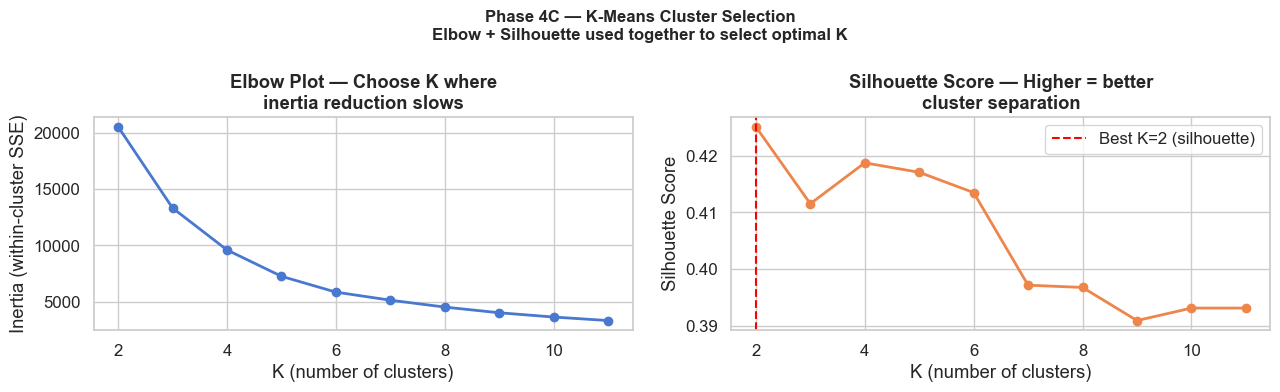


  Selected K = 2 (silhouette best=2, capped at 8)


In [10]:
# ════════════════════════════════════════════════════════════
# CELL 4C-K · CHOOSE OPTIMAL K (ELBOW + SILHOUETTE)
# ════════════════════════════════════════════════════════════

if GEO_AVAILABLE:
    coords = station_stats[["lat", "lon"]].values

    K_RANGE = range(2, 12)
    inertias     = []
    sil_scores   = []

    for k in K_RANGE:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(coords)
        inertias.append(km.inertia_)
        sil = silhouette_score(coords, labels) if k > 1 else float("nan")
        sil_scores.append(sil)
        print(f"  K={k:2d} | Inertia={km.inertia_:10.1f} | Silhouette={sil:.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(list(K_RANGE), inertias, marker="o", color=PAL[0], lw=2)
    axes[0].set_xlabel("K (number of clusters)")
    axes[0].set_ylabel("Inertia (within-cluster SSE)")
    axes[0].set_title("Elbow Plot — Choose K where\ninertia reduction slows",
                      fontweight="bold")

    axes[1].plot(list(K_RANGE), sil_scores, marker="o", color=PAL[1], lw=2)
    best_k_sil = list(K_RANGE)[int(np.argmax(sil_scores))]
    axes[1].axvline(best_k_sil, color="red", ls="--",
                    label=f"Best K={best_k_sil} (silhouette)")
    axes[1].set_xlabel("K (number of clusters)")
    axes[1].set_ylabel("Silhouette Score")
    axes[1].set_title("Silhouette Score — Higher = better\ncluster separation",
                      fontweight="bold")
    axes[1].legend()

    plt.suptitle("Phase 4C — K-Means Cluster Selection\n"
                 "Elbow + Silhouette used together to select optimal K",
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "p4_05_kmeans_k_selection.png", dpi=FIG_DPI, bbox_inches="tight")
    plt.show()

    # ── Final K selection ─────────────────────────────────────
    # Prefer silhouette best, but cap at 8 for interpretability.
    OPTIMAL_K = min(best_k_sil, 8)
    print(f"\n  Selected K = {OPTIMAL_K} (silhouette best={best_k_sil}, capped at 8)")


K-Means (K=2) fitted and saved -> outputs/models/p4_kmeans.pkl

Cluster summary (sorted by mean delay):


,n_stations,mean_delay,pct_severe,pct_delayed,center_lat,center_lon,rank
cluster,,,,,,,
1,2714,2.928,3.951,15.027,50.161,8.336,1
0,2558,2.148,2.687,9.934,51.163,11.974,2


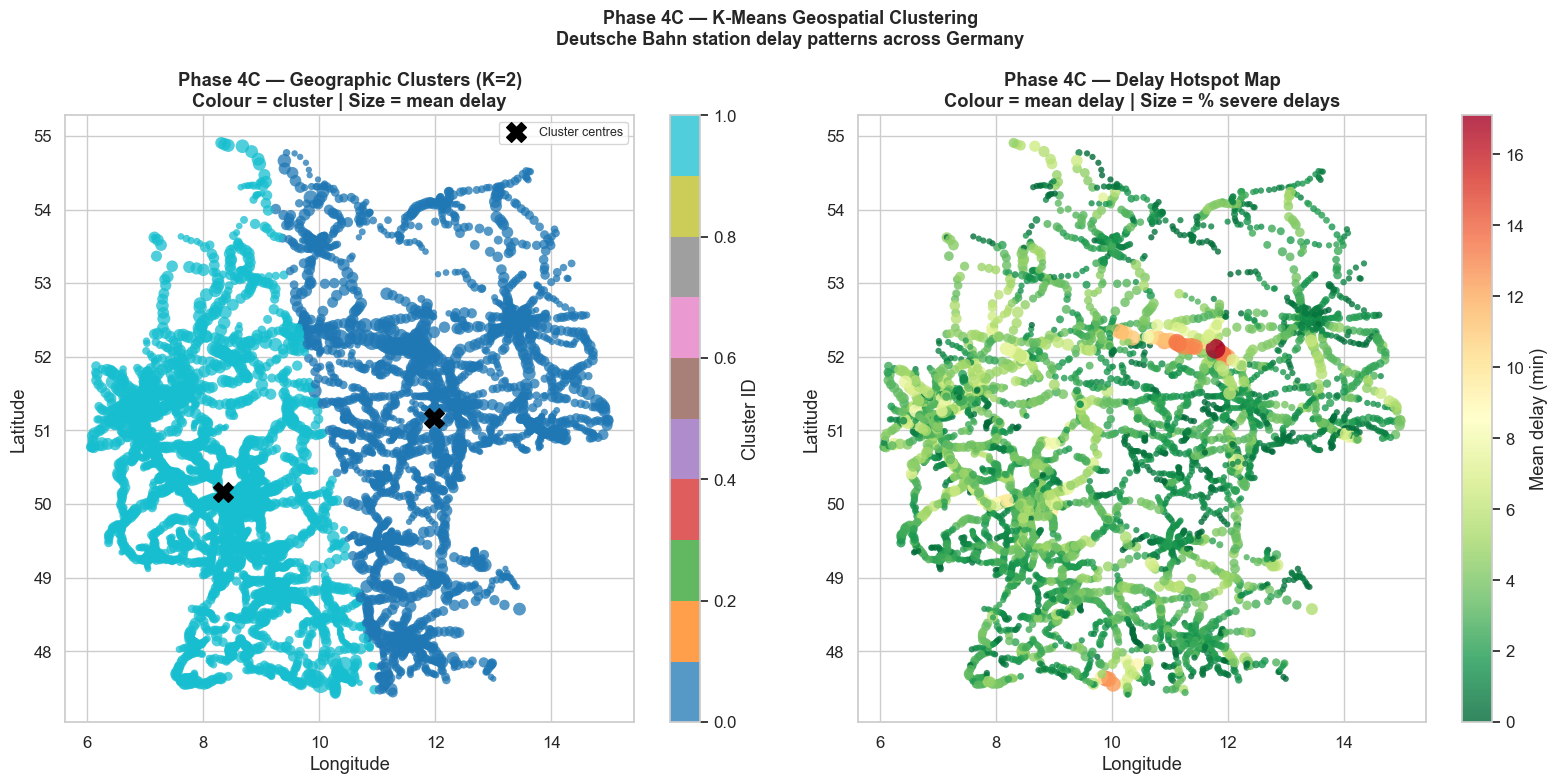

In [11]:
# ════════════════════════════════════════════════════════════
# CELL 4C-FIT · FIT FINAL K-MEANS & BUILD HOTSPOT MAP
# ════════════════════════════════════════════════════════════

if GEO_AVAILABLE:
    km_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=20)
    station_stats["cluster"] = km_final.fit_predict(
        station_stats[["lat", "lon"]].values
    )
    joblib.dump(km_final, MODEL_DIR / "p4_kmeans.pkl")
    print(f"K-Means (K={OPTIMAL_K}) fitted and saved -> outputs/models/p4_kmeans.pkl")

    # ── Cluster summary stats ─────────────────────────────────
    cluster_summary = (
        station_stats.groupby("cluster")
        .agg(
            n_stations  = ("station_name", "count"),
            mean_delay  = ("mean_delay",   "mean"),
            pct_severe  = ("pct_severe",   "mean"),
            pct_delayed = ("pct_delayed",  "mean"),
            center_lat  = ("lat", "mean"),
            center_lon  = ("lon", "mean"),
        )
        .round(3)
        .sort_values("mean_delay", ascending=False)
    )
    cluster_summary["rank"] = range(1, len(cluster_summary) + 1)
    print("\nCluster summary (sorted by mean delay):")
    display(cluster_summary)
    cluster_summary.to_csv(OUTPUT_DIR / "phase4_cluster_summary.csv")

    # ── Hotspot map ───────────────────────────────────────────
    CLUSTER_CMAP = plt.cm.get_cmap("tab10", OPTIMAL_K)
    cluster_colors = [CLUSTER_CMAP(c) for c in station_stats["cluster"]]

    # Marker size proportional to mean delay
    delay_min = station_stats["mean_delay"].min()
    delay_max = station_stats["mean_delay"].max()
    marker_sz  = 20 + 200 * (
        (station_stats["mean_delay"] - delay_min) /
        (delay_max - delay_min + 1e-9)
    )

    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    # Left: cluster membership coloured
    sc1 = axes[0].scatter(
        station_stats["lon"], station_stats["lat"],
        c=station_stats["cluster"], cmap="tab10",
        vmin=0, vmax=OPTIMAL_K - 1,
        s=marker_sz, alpha=0.75, edgecolors="none"
    )
    # Mark cluster centres
    centers = km_final.cluster_centers_
    axes[0].scatter(centers[:, 1], centers[:, 0],
                    c="black", marker="X", s=200, zorder=5,
                    label="Cluster centres")
    axes[0].set_xlabel("Longitude"); axes[0].set_ylabel("Latitude")
    axes[0].set_title(f"Phase 4C — Geographic Clusters (K={OPTIMAL_K})\n"
                      "Colour = cluster | Size = mean delay", fontweight="bold")
    plt.colorbar(sc1, ax=axes[0], label="Cluster ID")
    axes[0].legend(fontsize=9)

    # Right: mean delay heatmap (colour = mean delay, size = % severe)
    sc2 = axes[1].scatter(
        station_stats["lon"], station_stats["lat"],
        c=station_stats["mean_delay"],
        cmap="RdYlGn_r",
        s=20 + 180 * station_stats["pct_severe"] / station_stats["pct_severe"].max(),
        alpha=0.80, edgecolors="none"
    )
    plt.colorbar(sc2, ax=axes[1], label="Mean delay (min)")
    axes[1].set_xlabel("Longitude"); axes[1].set_ylabel("Latitude")
    axes[1].set_title("Phase 4C — Delay Hotspot Map\n"
                      "Colour = mean delay | Size = % severe delays", fontweight="bold")

    plt.suptitle("Phase 4C — K-Means Geospatial Clustering\n"
                 "Deutsche Bahn station delay patterns across Germany",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "p4_06_geo_clusters.png", dpi=FIG_DPI, bbox_inches="tight")
    plt.show()


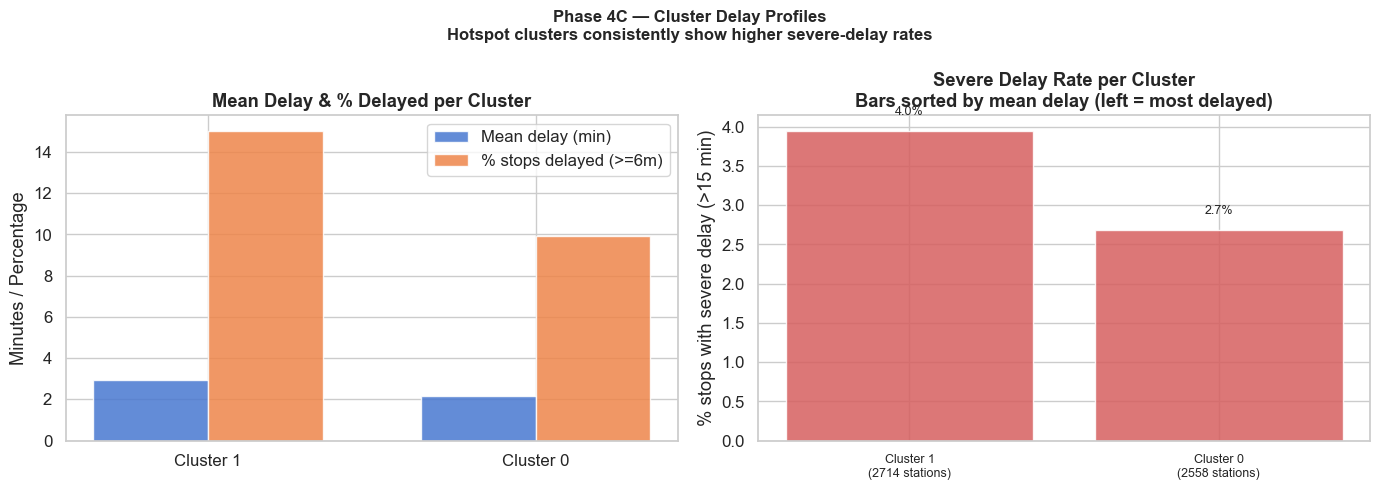

In [12]:
# ════════════════════════════════════════════════════════════
# CELL 4C-CHART 2 · CLUSTER DELAY PROFILES
# ════════════════════════════════════════════════════════════

if GEO_AVAILABLE:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    x = np.arange(len(cluster_summary))
    w = 0.35

    axes[0].bar(x - w/2, cluster_summary["mean_delay"],   w,
                label="Mean delay (min)", color=PAL[0], alpha=0.85)
    axes[0].bar(x + w/2, cluster_summary["pct_delayed"],  w,
                label="% stops delayed (>=6m)", color=PAL[1], alpha=0.85)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels([f"Cluster {c}" for c in cluster_summary.index])
    axes[0].set_ylabel("Minutes / Percentage")
    axes[0].set_title("Mean Delay & % Delayed per Cluster", fontweight="bold")
    axes[0].legend()

    axes[1].bar(x, cluster_summary["pct_severe"], color=PAL[3], alpha=0.85)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels([f"Cluster {c}\n({int(cluster_summary['n_stations'].iloc[i])} stations)"
                              for i, c in enumerate(cluster_summary.index)],
                             fontsize=9)
    axes[1].set_ylabel("% stops with severe delay (>15 min)")
    axes[1].set_title("Severe Delay Rate per Cluster\n"
                      "Bars sorted by mean delay (left = most delayed)",
                      fontweight="bold")
    for bar, val in zip(axes[1].patches, cluster_summary["pct_severe"]):
        axes[1].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.2, f"{val:.1f}%",
                     ha="center", fontsize=9)

    plt.suptitle("Phase 4C — Cluster Delay Profiles\n"
                 "Hotspot clusters consistently show higher severe-delay rates",
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "p4_07_cluster_profiles.png", dpi=FIG_DPI, bbox_inches="tight")
    plt.show()


In [15]:
# ════════════════════════════════════════════════════════════
# CELL 4D · TRANSFORMER (OPTIONAL / BONUS)
#
# A Transformer encoder processes the stop sequence using
# multi-head self-attention instead of recurrence.
#
# Self-attention: each stop attends to all other stops in
# the window simultaneously, capturing non-local dependencies
# (e.g. a delay spike 4 stops ago still directly influences
# the attention output).
#
# Architecture:
#   Input  : (LOOKBACK, N_FEATURES)
#   + Positional encoding (learnable)
#   TransformerEncoder block x2 (4 heads, ff_dim=64)
#   GlobalAveragePooling1D  (aggregate over sequence)
#   Dense 32 → ReLU → Dropout
#   Output : 1 unit, linear
# ════════════════════════════════════════════════════════════

print("\n" + "=" * 72)
print("  PHASE 4D — TRANSFORMER ENCODER (fixed)")
print("=" * 72)

# ─────────────────────────────────────────────────────────────
# Transformer encoder block
# ─────────────────────────────────────────────────────────────
def transformer_encoder_block(x, num_heads, ff_dim, dropout_rate=0.15):
    attn_out = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=x.shape[-1] // num_heads,
        dropout=dropout_rate
    )(x, x)

    x = layers.Add()([x, attn_out])
    x = layers.LayerNormalization(epsilon=1e-6)(x)

    ffn = layers.Dense(ff_dim, activation="relu")(x)
    ffn = layers.Dropout(dropout_rate)(ffn)
    ffn = layers.Dense(x.shape[-1])(ffn)

    x = layers.Add()([x, ffn])
    x = layers.LayerNormalization(epsilon=1e-6)(x)

    return x


# ─────────────────────────────────────────────────────────────
# Hyperparameters
# ─────────────────────────────────────────────────────────────
NUM_HEADS = 4
FF_DIM    = 64

# ─────────────────────────────────────────────────────────────
# Input
# ─────────────────────────────────────────────────────────────
tr_input = keras.Input(shape=(LOOKBACK, N_FEATURES), name="tr_input")

# ─────────────────────────────────────────────────────────────
# Positional Encoding (FIXED SHAPES)
# ─────────────────────────────────────────────────────────────
positions = tf.range(start=0, limit=LOOKBACK, delta=1)

pos_embed_layer = layers.Embedding(
    input_dim=LOOKBACK,
    output_dim=N_FEATURES,
    name="pos_embed"
)

pos_embed = pos_embed_layer(positions)        # (LOOKBACK, N_FEATURES)
pos_embed = tf.expand_dims(pos_embed, axis=0)  # (1, LOOKBACK, N_FEATURES)

tr_x = layers.Add(name="add_pos")([tr_input, pos_embed])

# ─────────────────────────────────────────────────────────────
# Transformer blocks
# ─────────────────────────────────────────────────────────────
tr_x = transformer_encoder_block(tr_x, NUM_HEADS, FF_DIM, 0.15)
tr_x = transformer_encoder_block(tr_x, NUM_HEADS, FF_DIM, 0.15)

# ─────────────────────────────────────────────────────────────
# Prediction head
# ─────────────────────────────────────────────────────────────
tr_x = layers.GlobalAveragePooling1D(name="global_avg_pool")(tr_x)
tr_x = layers.Dense(32, activation="relu")(tr_x)
tr_x = layers.Dropout(0.15)(tr_x)

tr_out = layers.Dense(1, activation="linear", name="output")(tr_x)

# ─────────────────────────────────────────────────────────────
# Model
# ─────────────────────────────────────────────────────────────
transformer_model = Model(inputs=tr_input, outputs=tr_out, name="Transformer_delay")

transformer_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-4),
    loss="mse",
    metrics=["mae"],
)

transformer_model.summary()

# ─────────────────────────────────────────────────────────────
# Training callbacks
# ─────────────────────────────────────────────────────────────
cb_tr = [
    K_CB.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    K_CB.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=0
    ),
]

# ─────────────────────────────────────────────────────────────
# Training
# ─────────────────────────────────────────────────────────────
t0 = time.time()

hist_tr = transformer_model.fit(
    X_seq_fit, y_seq_fit,
    validation_data=(X_seq_val, y_seq_val),
    epochs=60,
    batch_size=512,
    callbacks=cb_tr,
    verbose=1,
)

t1 = time.time()
train_time_tr = t1 - t0

# ─────────────────────────────────────────────────────────────
# Evaluation
# ─────────────────────────────────────────────────────────────
pred_tr_norm = transformer_model.predict(X_test_sc, verbose=0).flatten()
pred_tr = pred_tr_norm * y_std + y_mean

mae_tr  = mean_absolute_error(y_test_seq, pred_tr)
rmse_tr = float(np.sqrt(mean_squared_error(y_test_seq, pred_tr)))
r2_tr   = r2_score(y_test_seq, pred_tr)

print("\n  Transformer results:")
print(f"  MAE  : {mae_tr:.4f} min")
print(f"  RMSE : {rmse_tr:.4f} min")
print(f"  R²   : {r2_tr:.4f}")
print(f"  Time : {train_time_tr:.1f}s")

# ─────────────────────────────────────────────────────────────
# Save model
# ─────────────────────────────────────────────────────────────
transformer_model.save(str(MODEL_DIR / "p4_transformer.keras"))
print("  Saved -> outputs/models/p4_transformer.keras")



  PHASE 4D — TRANSFORMER ENCODER (fixed)
Model: "Transformer_delay"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 tr_input (InputLayer)          [(None, 5, 24)]      0           []                               
                                                                                                  
 add_pos (Add)                  (None, 5, 24)        0           ['tr_input[0][0]']               
                                                                                                  
 multi_head_attention_4 (MultiH  (None, 5, 24)       2400        ['add_pos[0][0]',                
 eadAttention)                                                    'add_pos[0][0]']                
                                                                                                  
 add_8 (Add)                    (None, 5

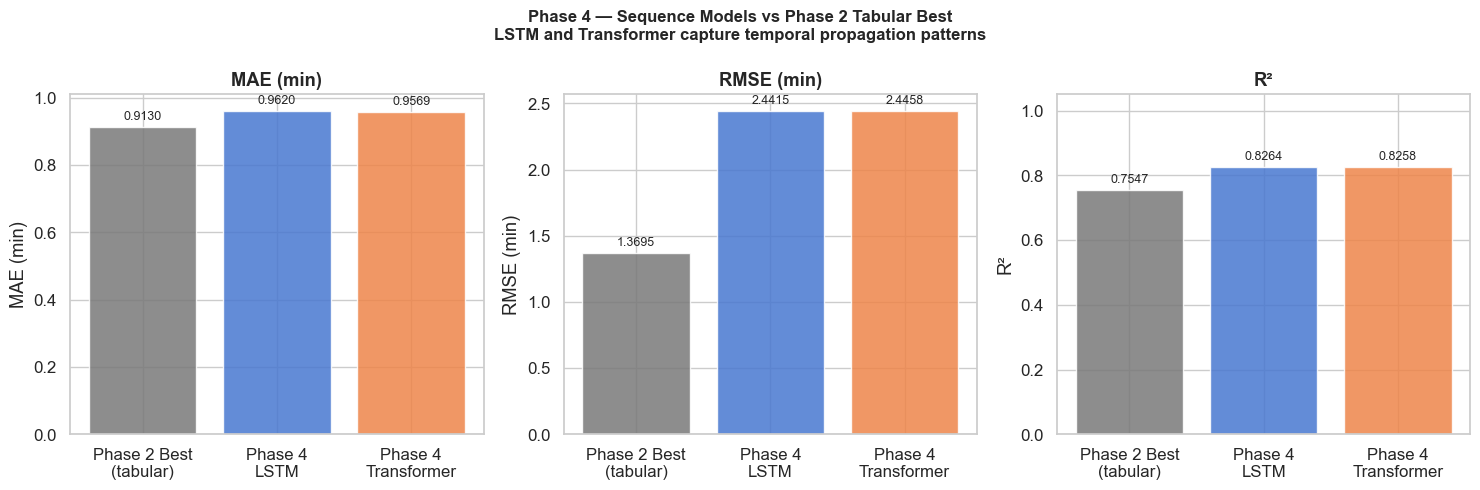

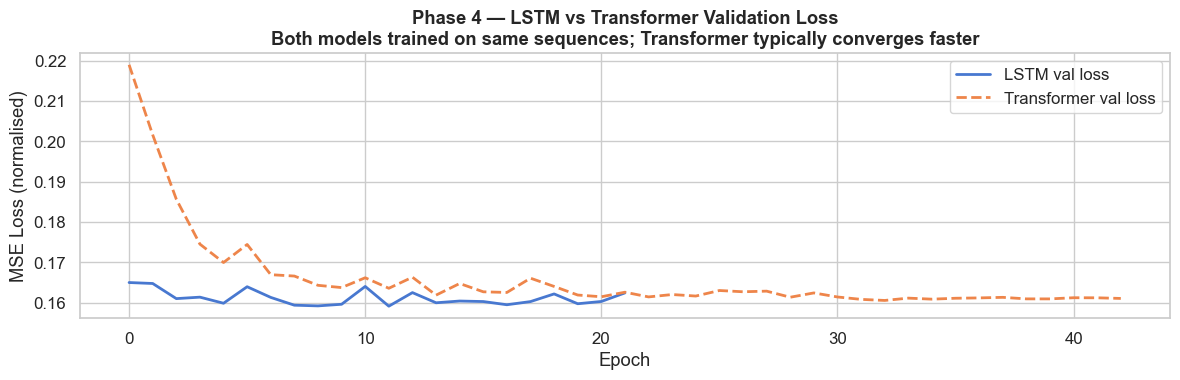

In [16]:
# ════════════════════════════════════════════════════════════
# CELL 4E · PHASE 4 MODEL COMPARISON CHART
#
# Compare Phase 4 sequence models (LSTM, Transformer)
# against Phase 2 tabular best model.
# ════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

model_names = ["Phase 2 Best\n(tabular)", "Phase 4\nLSTM", "Phase 4\nTransformer"]
maes        = [p2_cfg["best_mae"], mae_lstm, mae_tr]
rmses       = [p2_cfg.get("best_rmse",
               p2_cfg["best_mae"] * 1.5),  # fallback estimate if not saved
               rmse_lstm, rmse_tr]
r2s         = [p2_cfg.get("best_r2", float("nan")), r2_lstm, r2_tr]

bar_clrs = [PAL[7], PAL[0], PAL[1]]

for ax, vals, metric in zip(axes,
                              [maes, rmses, r2s],
                              ["MAE (min)", "RMSE (min)", "R²"]):
    bars = ax.bar(model_names, vals, color=bar_clrs, alpha=0.85)
    ax.bar_label(bars, fmt="%.4f", padding=3, fontsize=9)
    ax.set_ylabel(metric)
    ax.set_title(metric, fontweight="bold")
    if metric == "R²":
        ax.set_ylim(0, 1.05)

plt.suptitle("Phase 4 — Sequence Models vs Phase 2 Tabular Best\n"
             "LSTM and Transformer capture temporal propagation patterns",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "p4_08_model_comparison.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

# Training curve comparison
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(hist_lstm.history["val_loss"], label="LSTM val loss", color=PAL[0], lw=2)
ax.plot(hist_tr.history["val_loss"],   label="Transformer val loss", color=PAL[1],
        lw=2, ls="--")
ax.set_xlabel("Epoch"); ax.set_ylabel("MSE Loss (normalised)")
ax.set_title("Phase 4 — LSTM vs Transformer Validation Loss\n"
             "Both models trained on same sequences; Transformer typically converges faster",
             fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "p4_09_lstm_vs_transformer.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()


In [17]:
# ════════════════════════════════════════════════════════════
# CELL 5 · SAVE OUTPUTS & PHASE 4 CONFIG
# ════════════════════════════════════════════════════════════

# ── Save sequence predictions ─────────────────────────────────
seq_pred_df = pd.DataFrame({
    "ride_id"          : test_ride_ids,
    "stop_num"         : test_stop_nums,
    "actual_delay"     : y_test_seq,
    "lstm_pred"        : pred_lstm,
    "transformer_pred" : pred_tr,
    "lstm_residual"    : y_test_seq - pred_lstm,
    "tr_residual"      : y_test_seq - pred_tr,
})
seq_pred_df.to_parquet(OUTPUT_DIR / "phase4_sequence_predictions.parquet", index=False)
print("Sequence predictions -> outputs/phase4_sequence_predictions.parquet")

# ── Phase 4 config (for Phase 5) ──────────────────────────────
phase4_cfg = {
    "LOOKBACK"            : LOOKBACK,
    "SEQ_FEATURES"        : SEQ_FEATURES,
    "N_FEATURES"          : N_FEATURES,
    "y_mean"              : y_mean,
    "y_std"               : y_std,
    "lstm_mae"            : float(mae_lstm),
    "lstm_rmse"           : float(rmse_lstm),
    "lstm_r2"             : float(r2_lstm),
    "transformer_mae"     : float(mae_tr),
    "transformer_rmse"    : float(rmse_tr),
    "transformer_r2"      : float(r2_tr),
    "autoencoder_threshold": float(ANOMALY_THRESHOLD),
    "n_anomalies_test"    : int(n_anomalies),
    "pct_anomalies_test"  : float(n_anomalies / len(test_recon_err) * 100),
    "geo_available"       : GEO_AVAILABLE,
    "optimal_k"           : int(OPTIMAL_K) if GEO_AVAILABLE else None,
    "p2_best_mae"         : p2_cfg["best_mae"],
    "p2_best_model"       : p2_cfg["best_model_name"],
}
with open(OUTPUT_DIR / "phase4_config.json", "w") as f:
    json.dump(phase4_cfg, f, indent=2)
print("Phase 4 config   -> outputs/phase4_config.json")

print("\nAll Phase 4 model files:")
for p in sorted(MODEL_DIR.glob("p4_*")):
    print(f"  {p}")


Sequence predictions -> outputs/phase4_sequence_predictions.parquet
Phase 4 config   -> outputs/phase4_config.json

All Phase 4 model files:
  outputs\models\p4_autoencoder.keras
  outputs\models\p4_kmeans.pkl
  outputs\models\p4_lstm.keras
  outputs\models\p4_seq_scaler.pkl
  outputs\models\p4_transformer.keras


In [18]:
# ════════════════════════════════════════════════════════════
# CELL 6 · FINAL SUMMARY
# ════════════════════════════════════════════════════════════

sep = "=" * 72
print(sep)
print("  PHASE 4 COMPLETE -- Deep Learning & Geospatial")
print(sep)
print("")
print("  4A — LSTM Delay Sequence Model")
print(f"       MAE  : {mae_lstm:.4f} min")
print(f"       RMSE : {rmse_lstm:.4f} min")
print(f"       R2   : {r2_lstm:.4f}")
print(f"       Lookback window : {LOOKBACK} stops")
print(f"       Features        : {N_FEATURES}")
print("")
print("  4B — Autoencoder Anomaly Detection")
print(f"       Bottleneck dim  : {BOTTLENECK}")
print(f"       Threshold (95th): {ANOMALY_THRESHOLD:.6f}")
print(f"       Anomalous stops : {n_anomalies:,} / {len(test_recon_err):,}"
      f"  ({n_anomalies/len(test_recon_err)*100:.1f}%)")
print(f"       Mean delay anomalous: {mean_anomaly:.2f} min vs"
      f" normal: {mean_normal:.2f} min")
print("")
if GEO_AVAILABLE:
    print("  4C — Geospatial K-Means Clustering")
    print(f"       Optimal K  : {OPTIMAL_K}")
    print(f"       Stations   : {len(station_stats):,}")
    print(f"       Saved      : outputs/phase4_cluster_summary.csv")
else:
    print("  4C — Geospatial Clustering: SKIPPED (lat/lon not available)")
print("")
print("  4D — Transformer Encoder (bonus)")
print(f"       MAE  : {mae_tr:.4f} min")
print(f"       RMSE : {rmse_tr:.4f} min")
print(f"       R2   : {r2_tr:.4f}")
print("")
print(f"  Phase 2 tabular best for comparison:")
print(f"       {p2_cfg['best_model_name']}: MAE = {p2_cfg['best_mae']:.4f} min")
print("")
print(sep)
print("  Outputs:")
print("    outputs/phase4_sequence_predictions.parquet")
print("    outputs/phase4_anomaly_results.parquet")
print("    outputs/phase4_cluster_summary.csv")
print("    outputs/phase4_config.json")
print("    outputs/models/p4_lstm.keras")
print("    outputs/models/p4_autoencoder.keras")
print("    outputs/models/p4_transformer.keras")
print("    outputs/models/p4_kmeans.pkl")
print("    outputs/models/p4_seq_scaler.pkl")
print("    outputs/figures/p4_01 to p4_09  (9 charts)")
print(sep)
print("  Next: Phase 5 -> Interpretability & Insights")
print("    SHAP analysis, delay heatmaps, network graph")
print(sep)


  PHASE 4 COMPLETE -- Deep Learning & Geospatial

  4A — LSTM Delay Sequence Model
       MAE  : 0.9620 min
       RMSE : 2.4415 min
       R2   : 0.8264
       Lookback window : 5 stops
       Features        : 24

  4B — Autoencoder Anomaly Detection
       Bottleneck dim  : 8
       Threshold (95th): 0.337510
       Anomalous stops : 8,016 / 149,685  (5.4%)
       Mean delay anomalous: 6.10 min vs normal: 2.61 min

  4C — Geospatial K-Means Clustering
       Optimal K  : 2
       Stations   : 5,272
       Saved      : outputs/phase4_cluster_summary.csv

  4D — Transformer Encoder (bonus)
       MAE  : 0.9569 min
       RMSE : 2.4458 min
       R2   : 0.8258

  Phase 2 tabular best for comparison:
       MLP Neural Network: MAE = 0.9130 min

  Outputs:
    outputs/phase4_sequence_predictions.parquet
    outputs/phase4_anomaly_results.parquet
    outputs/phase4_cluster_summary.csv
    outputs/phase4_config.json
    outputs/models/p4_lstm.keras
    outputs/models/p4_autoencoder.keras
 